In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from openpyxl import Workbook

print("All good")

All good


In [97]:
# Read Data
rev = pd.read_excel('data/Case_Study_Dataset__1_.xlsx', sheet_name='Revenue')
streams = pd.read_excel('data/Case_Study_Dataset__1_.xlsx', sheet_name='Streams')

print("rev shape:", rev.shape)
print(rev.head(3))

print("\n\n")

print("streams shape:", streams.shape)
print(streams.head(3))


rev shape: (3534, 5)
       month business_unit                                 dsp territory_name  \
0 2025-09-01          BU 2  YouTube Premium Individual monthly         Brazil   
1 2025-10-01          BU 2  YouTube Premium Individual monthly         Canada   
2 2025-02-01          BU 3                        Apple/iTunes         Brazil   

   total_gross_amount  
0                 1.0  
1                 2.0  
2                 0.0  



streams shape: (26036, 5)
       month business_unit      dsp         country  total_streams
0 2025-01-01          BU 2   TikTok          Norway      111404358
1 2025-01-01          BU 4   TikTok  Western Sahara              0
2 2025-01-01          BU 4  Spotify          Brazil       47472830


In [98]:
print(rev['dsp'].unique())

<StringArray>
[     'YouTube Premium Individual monthly',
                            'Apple/iTunes',
                    'Apple Music Dj Mixes',
                             'Apple Music',
                           'YouTube - Ads',
                                 'Spotify',
                       'YouTube - Premium',
                      'YouTube Ad Revenue',
                                  'Amazon',
          'YouTube Premium Family monthly',
                    'YouTube - Audio Tier',
                            'Amazon Prime',
                                 'YouTube',
         'YouTube Premium Student monthly',
                        'Amazon Unlimited',
            'YouTube Music Family monthly',
           'YouTube Music Student monthly',
                     'Amazon Ad Supported',
                                  'Tiktok',
                           'YouTube Music',
        'YouTube Music Individual monthly',
 'YouTube Premium Lite Individual monthly',
                  

In [99]:
print(streams['dsp'].unique())


<StringArray>
['TikTok', 'Spotify', 'Amazon', 'Apple', 'YouTube']
Length: 5, dtype: str


In [100]:
# Clean and Standardize

#dsp mapping for revenue -> streams dsp

dsp_map = {
    'Spotify': 'Spotify',
    'YouTube': 'YouTube',
    'YouTube Premium': 'YouTube',
    'YouTube - Ads': 'YouTube',
    'YouTube - Premium': 'YouTube',
    'YouTube Ad Revenue': 'YouTube',
    'YouTube - Audio Tier': 'YouTube',
    'YouTube Music': 'YouTube',
    'YouTube Music Family monthly': 'YouTube',
    'YouTube Music Individual monthly': 'YouTube',
    'YouTube Music Student monthly': 'YouTube',
    'YouTube Premium Family monthly': 'YouTube',
    'YouTube Premium Individual monthly': 'YouTube',
    'YouTube Premium Lite Individual monthly': 'YouTube',
    'YouTube Premium Student monthly': 'YouTube',
    'Youtube Licensing': 'YouTube',
    'YouTube - Other': 'YouTube',
    'Apple Inc.': 'Apple',
    'Apple Music': 'Apple',
    'Apple/iTunes': 'Apple',
    'Apple Music Dj Mixes': 'Apple',
    'Tiktok': 'TikTok',
    'Amazon': 'Amazon',
    'Amazon Prime': 'Amazon',
    'Amazon Unlimited': 'Amazon',
    'Amazon Ad Supported': 'Amazon',
    'Amazon Cloud': 'Amazon',
}

#apply mapping to rev dsp column
rev['dsp_clean'] = rev['dsp'].map(dsp_map)

In [101]:
#Checking if any records dsp didn't get mapped to one of the main 5 bucket dsps

# Check if any DSPs didn't get mapped
unmapped = rev[rev['dsp_clean'].isna()]['dsp'].unique()
print("Unmapped DSPs:", unmapped)


Unmapped DSPs: <StringArray>
[]
Length: 0, dtype: str


In [102]:

# Rename territory to consistent name (country as per streams table)
rev = rev.rename(columns={'territory_name': 'country'})


In [103]:
#since data per record is monthly (every row represents full month's worth but this raw data has date too, we'll clean the month col)

rev['month'] = pd.to_datetime(rev['month']).dt.to_period('M')
streams['month'] = pd.to_datetime(streams['month']).dt.to_period('M')

In [104]:

# Check nulls across both dataframes
print("Revenue nulls:")
print(rev.isnull().sum())

print("\nStreams nulls:")
print(streams.isnull().sum())

#check which ones are null
print(rev[rev['total_gross_amount'].isna()])



Revenue nulls:
month                 0
business_unit         0
dsp                   0
country               0
total_gross_amount    9
dsp_clean             0
dtype: int64

Streams nulls:
month            0
business_unit    0
dsp              0
country          0
total_streams    0
dtype: int64
        month business_unit          dsp  country  total_gross_amount  \
26    2025-04          BU 3  Apple Music   France                 NaN   
417   2025-02          BU 3  Apple Music   Mexico                 NaN   
616   2025-04          BU 3  Apple Music    India                 NaN   
1033  2025-01          BU 3  Apple Music  Germany                 NaN   
1217  2025-02          BU 3  Apple Music  Germany                 NaN   
1356  2025-08          BU 3  Apple Music   Mexico                 NaN   
1897  2025-04          BU 3  Apple Music  Germany                 NaN   
2378  2025-07          BU 3  Apple Music   Brazil                 NaN   
2782  2025-03          BU 3  Apple Music   Fran

In [105]:

# All 9 nulls are Apple Music, BU 3, spread across different countries and months. No pattern that suggests a
#data loading issue - these are just missing statements from Apple for that BU.

# Filling with 0 is the right call here. These are genuinely missing payouts, not a data error.

rev['total_gross_amount'] = rev['total_gross_amount'].fillna(0)
print("Nulls remaining:", rev['total_gross_amount'].isna().sum())

Nulls remaining: 0


In [106]:
rev_countries = set(rev['country'].unique())
str_countries = set(streams['country'].unique())

print("Countries in Revenue but NOT in Streams:")
print(rev_countries - str_countries)

print("\nCountries in Streams but NOT in Revenue:")
print(str_countries - rev_countries)

print("\nCountries in both:")
print(rev_countries & str_countries)


Countries in Revenue but NOT in Streams:
set()

Countries in Streams but NOT in Revenue:
{'Lebanon', 'Saint Barthélemy', 'Czechia', 'ROW', 'Switzerland', 'Trinidad and Tobago', 'Cayman Islands', 'Nigeria', 'Cabo Verde', 'Guinea-Bissau', 'Mali', 'Åland Islands', 'Fiji', 'Tajikistan', 'Guinea', 'Northern Mariana Islands', 'Nauru', 'Denmark', 'Papua New Guinea', 'Congo, Democratic Republic of the', 'Luxembourg', 'Pitcairn', 'Suriname', 'Hungary', 'Bhutan', 'Sint Maarten (Dutch part)', 'Gibraltar', 'Croatia', 'Holy See', 'El Salvador', 'Indonesia', 'Angola', 'Seychelles', 'Jordan', 'Eritrea', 'French Guiana', 'Puerto Rico', 'Iceland', 'Cuba', 'Antigua and Barbuda', 'Martinique', 'Turkmenistan', 'Tokelau', 'Saint Martin (French part)', 'French Southern Territories', 'Norfolk Island', 'Mayotte', 'Turks and Caicos Islands', 'Maldives', 'Syrian Arab Republic', 'Gabon', 'Algeria', 'Argentina', 'Anguilla', 'Montenegro', 'Russian Federation', 'Latvia', 'Rwanda', 'Macao', 'Costa Rica', 'Saint Luci

In [107]:
print(sorted(rev['country'].unique()))


['All Other Locations', 'Australia', 'Brazil', 'Canada', 'France', 'Germany', 'India', 'Mexico', 'United Kingdom', 'United States of America']


In [108]:
streams['country'] = streams['country'].apply(lambda x: x if x in rev_countries else "All Other Locations")

In [109]:
streams['country'].unique()

<StringArray>
[     'All Other Locations',                   'Brazil',
           'United Kingdom',                    'India',
                   'France',                   'Mexico',
                   'Canada',                  'Germany',
 'United States of America',                'Australia']
Length: 10, dtype: str

In [110]:
rev['country'].unique()

<StringArray>
[                  'Brazil',                   'Canada',
 'United States of America',                  'Germany',
           'United Kingdom',      'All Other Locations',
                   'France',                    'India',
                'Australia',                   'Mexico']
Length: 10, dtype: str

In [111]:
streams.head()

,month,business_unit,dsp,country,total_streams
0,2025-01,BU 2,TikTok,All Other Locations,111404358
1,2025-01,BU 4,TikTok,All Other Locations,0
2,2025-01,BU 4,Spotify,Brazil,47472830
3,2025-01,BU 2,Amazon,All Other Locations,0
4,2025-01,BU 4,TikTok,All Other Locations,318687573


In [112]:
rev.head()

,month,business_unit,dsp,country,total_gross_amount,dsp_clean
0,2025-09,BU 2,YouTube Premium Individual monthly,Brazil,1.0,YouTube
1,2025-10,BU 2,YouTube Premium Individual monthly,Canada,2.0,YouTube
2,2025-02,BU 3,Apple/iTunes,Brazil,0.0,Apple
3,2025-02,BU 1,Apple Music Dj Mixes,United States of America,5.0,Apple
4,2025-05,BU 3,Apple Music,Brazil,0.0,Apple


In [118]:
streams_grouped = streams.groupby(['month','dsp', 'business_unit','country'])['total_streams'].sum().reset_index()
print(streams_grouped.head())
print(streams_grouped.shape)

     month     dsp business_unit              country  total_streams
0  2025-01  Amazon          BU 1  All Other Locations         526881
1  2025-01  Amazon          BU 1            Australia          32830
2  2025-01  Amazon          BU 1               Brazil          77591
3  2025-01  Amazon          BU 1               Canada          79619
4  2025-01  Amazon          BU 1               France         115564
(2000, 5)


In [126]:
rev_grouped = rev.groupby(['month','dsp_clean', 'business_unit','country'])['total_gross_amount'].sum().reset_index()
print(rev_grouped.head())
print(rev_grouped.shape)

     month dsp_clean business_unit              country  total_gross_amount
0  2025-01    Amazon          BU 1  All Other Locations              3431.0
1  2025-01    Amazon          BU 1            Australia               219.0
2  2025-01    Amazon          BU 1               Brazil               245.0
3  2025-01    Amazon          BU 1               Canada              1878.0
4  2025-01    Amazon          BU 1               France               765.0
(1812, 5)


In [128]:
merged = streams_grouped.merge(rev_grouped,how = 'left', left_on = ['month','dsp','business_unit','country'], right_on = ['month','dsp_clean','business_unit','country'])   
merged = merged.drop("dsp_clean",axis = 1)
print(merged.head())
print(merged.shape)

     month     dsp business_unit              country  total_streams  \
0  2025-01  Amazon          BU 1  All Other Locations         526881   
1  2025-01  Amazon          BU 1            Australia          32830   
2  2025-01  Amazon          BU 1               Brazil          77591   
3  2025-01  Amazon          BU 1               Canada          79619   
4  2025-01  Amazon          BU 1               France         115564   

   total_gross_amount  
0              3431.0  
1               219.0  
2               245.0  
3              1878.0  
4               765.0  
(2000, 6)


In [130]:
#rows where null revenue but streams data exist (combination of dsp, month, country, BU)
print("Null revenue rows after merge:", merged['total_gross_amount'].isna().sum())


Null revenue rows after merge: 188


In [131]:
merged[merged['total_gross_amount'] > 0]['total_gross_amount'].describe()


count    1.714000e+03
mean     5.855471e+04
std      1.771708e+05
min      1.000000e+00
25%      1.616500e+03
50%      9.028000e+03
75%      3.676150e+04
max      2.226002e+06
Name: total_gross_amount, dtype: float64

In [140]:
#if a rose revenue is less than 20% of that DSP is used for a monthly average we flag it as a forecast otherwise actually

In [143]:
filtered = merged[merged['month'].astype(str) <= '2025-08']

# Step 1: total revenue per DSP per month
dsp_monthly = filtered.groupby(['month', 'dsp'])['total_gross_amount'].sum().reset_index()


# Step 2: average across months per DSP
dsp_avg = dsp_monthly.groupby('dsp')['total_gross_amount'].mean().reset_index()
print(dsp_avg)

       dsp  total_gross_amount
0   Amazon          250070.500
1    Apple         1558758.875
2  Spotify         4745027.625
3   TikTok          345176.500
4  YouTube         4765669.250


In [144]:
# 20% threshold per DSP
dsp_avg['threshold'] = dsp_avg['total_gross_amount']*0.20
dsp_avg

,dsp,total_gross_amount,threshold
0,Amazon,250070.500,50014.100
1,Apple,1558758.875,311751.775
2,Spotify,4745027.625,949005.525
3,TikTok,345176.500,69035.300
4,YouTube,4765669.250,953133.850


In [145]:
merged = merged.merge(dsp_avg[['dsp', 'threshold']], on='dsp', how='left')

In [149]:
# Create flag column
merged['flag'] = merged.apply(
    lambda row: 'Forecast' if (pd.isna(row['total_gross_amount']) or row['total_gross_amount'] < row['threshold']) else 'Actual',
    axis=1
)

# Check flag distribution
print(merged['flag'].value_counts())

flag
Forecast    1967
Actual        33
Name: count, dtype: int64


In [150]:
print(dsp_avg.columns)
print(dsp_avg)

Index(['dsp', 'total_gross_amount', 'threshold'], dtype='str')
       dsp  total_gross_amount   threshold
0   Amazon          250070.500   50014.100
1    Apple         1558758.875  311751.775
2  Spotify         4745027.625  949005.525
3   TikTok          345176.500   69035.300
4  YouTube         4765669.250  953133.850


In [151]:
# Step 4: sum revenue per DSP+month in full dataset
dsp_month_totals = merged.groupby(['month', 'dsp'])['total_gross_amount'].sum().reset_index()
dsp_month_totals.columns = ['month', 'dsp', 'monthly_total']

# Merge threshold into dsp_month_totals
dsp_month_totals = dsp_month_totals.merge(dsp_avg[['dsp', 'threshold']], on='dsp', how='left')

# Flag at DSP+month level
dsp_month_totals['flag'] = dsp_month_totals.apply(
    lambda row: 'Forecast' if (pd.isna(row['monthly_total']) or row['monthly_total'] < row['threshold']) else 'Actual',
    axis=1
)

print(dsp_month_totals[['month','dsp','monthly_total','threshold','flag']])

      month      dsp  monthly_total   threshold      flag
0   2025-01   Amazon       216802.0   50014.100    Actual
1   2025-01    Apple      1680590.0  311751.775    Actual
2   2025-01  Spotify      4183147.0  949005.525    Actual
3   2025-01   TikTok       406774.0   69035.300    Actual
4   2025-01  YouTube      3989287.0  953133.850    Actual
5   2025-02   Amazon       214406.0   50014.100    Actual
6   2025-02    Apple      1356218.0  311751.775    Actual
7   2025-02  Spotify      4193729.0  949005.525    Actual
8   2025-02   TikTok       377892.0   69035.300    Actual
9   2025-02  YouTube      4293977.0  953133.850    Actual
10  2025-03   Amazon       230442.0   50014.100    Actual
11  2025-03    Apple      1525051.0  311751.775    Actual
12  2025-03  Spotify      4726346.0  949005.525    Actual
13  2025-03   TikTok       367880.0   69035.300    Actual
14  2025-03  YouTube      4801879.0  953133.850    Actual
15  2025-04   Amazon       248570.0   50014.100    Actual
16  2025-04   

In [152]:
merged = merged.merge(dsp_month_totals[['month','dsp','flag']], on=['month','dsp'], how='left')
print(merged['flag'].value_counts())

KeyError: 'flag'

In [154]:
merged = merged.drop(columns=['threshold', 'flag_x', 'flag_y'])
merged = merged.merge(dsp_month_totals[['month','dsp','flag']], on=['month','dsp'], how='left')
print(merged['flag'].value_counts())
print(merged.columns.tolist())


flag
Actual      1720
Forecast     280
Name: count, dtype: int64
['month', 'dsp', 'business_unit', 'country', 'total_streams', 'total_gross_amount', 'flag']


In [155]:
print(merged[merged['flag']=='Forecast'].groupby(['month','dsp']).size().reset_index(name='row_count'))


     month      dsp  row_count
0  2025-09   Amazon         40
1  2025-09  Spotify         40
2  2025-10   Amazon         40
3  2025-10    Apple         40
4  2025-10  Spotify         40
5  2025-10   TikTok         40
6  2025-10  YouTube         40


In [159]:
merged.head()

,month,dsp,business_unit,country,total_streams,total_gross_amount,flag
0,2025-01,Amazon,BU 1,All Other Locations,526881,3431.0,Actual
1,2025-01,Amazon,BU 1,Australia,32830,219.0,Actual
2,2025-01,Amazon,BU 1,Brazil,77591,245.0,Actual
3,2025-01,Amazon,BU 1,Canada,79619,1878.0,Actual
4,2025-01,Amazon,BU 1,France,115564,765.0,Actual


In [162]:
#EDA for what months to do RPS forecast using
streams_grouped.head(1)

,month,dsp,business_unit,country,total_streams
0,2025-01,Amazon,BU 1,All Other Locations,526881


In [168]:
step1 = streams_grouped.groupby(['month', 'dsp'])['total_streams'].sum().reset_index()
dsp_month_totals = dsp_month_totals.merge(step1, on = ['month','dsp'])
dsp_month_totals['RPS'] = dsp_month_totals['monthly_total']/dsp_month_totals['total_streams']*1000000


In [169]:
dsp_month_totals.head(10)

,month,dsp,monthly_total,threshold,flag,total_streams,RPS
0,2025-01,Amazon,216802.0,50014.100,Actual,31468721,6889.444283
1,2025-01,Apple,1680590.0,311751.775,Actual,261099748,6436.582237
2,2025-01,Spotify,4183147.0,949005.525,Actual,2005308423,2086.036717
3,2025-01,TikTok,406774.0,69035.300,Actual,85240854071,4.772054
4,2025-01,YouTube,3989287.0,953133.850,Actual,23816109638,167.503722
5,2025-02,Amazon,214406.0,50014.100,Actual,29556932,7254.000517
6,2025-02,Apple,1356218.0,311751.775,Actual,220302612,6156.159419
7,2025-02,Spotify,4193729.0,949005.525,Actual,1888209263,2221.008594
8,2025-02,TikTok,377892.0,69035.300,Actual,91680748589,4.121825
9,2025-02,YouTube,4293977.0,953133.850,Actual,25446910362,168.742568


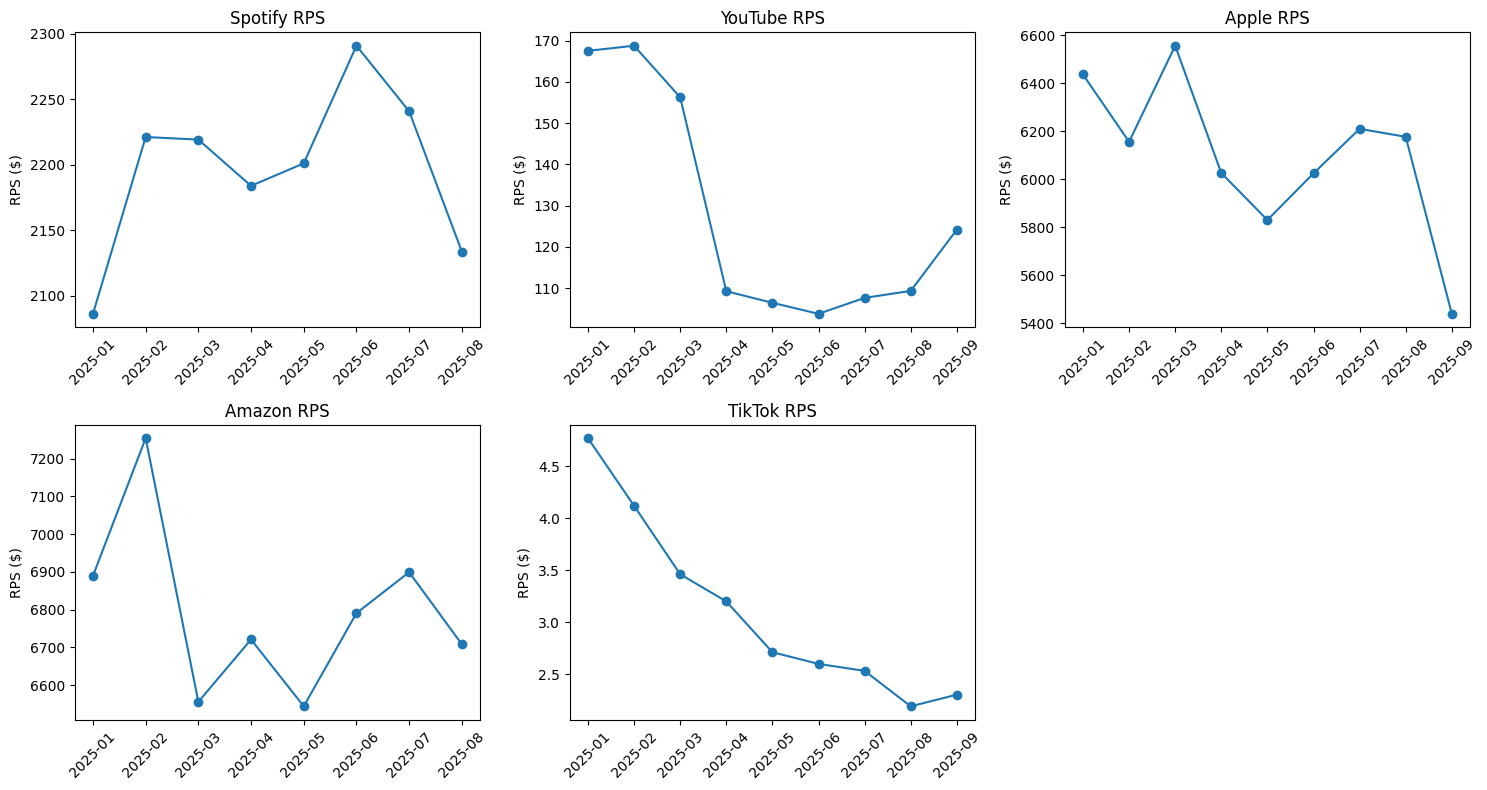

In [170]:
import matplotlib.pyplot as plt

# Only plot complete months
complete = dsp_month_totals[dsp_month_totals['flag'] == 'Actual']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, dsp in enumerate(['Spotify', 'YouTube', 'Apple', 'Amazon', 'TikTok']):
    df = complete[complete['dsp'] == dsp].sort_values('month')
    axes[i].plot(df['month'].astype(str), df['RPS'], marker='o')
    axes[i].set_title(f'{dsp} RPS')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('RPS ($)')

axes[5].set_visible(False)
plt.tight_layout()
plt.savefig('output/rps_trends.png', dpi=150)
plt.show()

In [171]:
for dsp in ['Spotify', 'YouTube', 'Apple', 'Amazon', 'TikTok']:
    df = complete[complete['dsp']==dsp]['RPS']
    cov = df.std() / df.mean()
    print(f'{dsp} CoV: {cov:.3f}')

Spotify CoV: 0.029
YouTube CoV: 0.217
Apple CoV: 0.054
Amazon CoV: 0.034
TikTok CoV: 0.283


# Forecasting

In [175]:
dsp_month_totals_filtered = dsp_month_totals[dsp_month_totals['month'].astype(str).isin(['2025-06', '2025-07', '2025-08'])]
dsp_month_totals_filtered

,month,dsp,monthly_total,threshold,flag,total_streams,RPS
25,2025-06,Amazon,262495.0,50014.100,Actual,38656605,6790.430769
26,2025-06,Apple,1392448.0,311751.775,Actual,231122942,6024.706972
27,2025-06,Spotify,4975451.0,949005.525,Actual,2172034897,2290.686493
28,2025-06,TikTok,299480.0,69035.300,Actual,115212435114,2.599372
29,2025-06,YouTube,5093214.0,953133.850,Actual,49069514541,103.795891
30,2025-07,Amazon,281382.0,50014.100,Actual,40785101,6899.137016
31,2025-07,Apple,1887546.0,311751.775,Actual,303947427,6210.106855
32,2025-07,Spotify,5179524.0,949005.525,Actual,2311557787,2240.707124
33,2025-07,TikTok,309566.0,69035.300,Actual,122257709991,2.532078
34,2025-07,YouTube,5116101.0,953133.850,Actual,47520200941,107.661603


In [176]:
# Jun-Aug baseline for all DSPs except YouTube
non_yt_baseline = dsp_month_totals_filtered[dsp_month_totals_filtered['dsp'] != 'YouTube']

# Apr-Aug baseline for YouTube only
yt_baseline = dsp_month_totals[
    (dsp_month_totals['dsp'] == 'YouTube') & 
    (dsp_month_totals['month'].astype(str) >= '2025-04') &
    (dsp_month_totals['month'].astype(str) <= '2025-08')
]

In [177]:
print(non_yt_baseline.groupby('dsp')['RPS'].mean())
print(yt_baseline['RPS'].mean())

dsp
Amazon     6799.238959
Apple      6137.247333
Spotify    2221.663720
TikTok        2.440821
Name: RPS, dtype: float64
107.3076027608743


In [178]:
# Combine into one RPS baseline per DSP
non_yt_rps = non_yt_baseline.groupby('dsp')['RPS'].mean().reset_index()
yt_rps = pd.DataFrame({'dsp': ['YouTube'], 'RPS': [yt_baseline['RPS'].mean()]})

rps_baseline = pd.concat([non_yt_rps, yt_rps], ignore_index=True)
rps_baseline.columns = ['dsp', 'rps_baseline']
print(rps_baseline)

       dsp  rps_baseline
0   Amazon   6799.238959
1    Apple   6137.247333
2  Spotify   2221.663720
3   TikTok      2.440821
4  YouTube    107.307603


In [179]:
merged.head()

,month,dsp,business_unit,country,total_streams,total_gross_amount,flag
0,2025-01,Amazon,BU 1,All Other Locations,526881,3431.0,Actual
1,2025-01,Amazon,BU 1,Australia,32830,219.0,Actual
2,2025-01,Amazon,BU 1,Brazil,77591,245.0,Actual
3,2025-01,Amazon,BU 1,Canada,79619,1878.0,Actual
4,2025-01,Amazon,BU 1,France,115564,765.0,Actual


In [180]:
merged = merged.merge(rps_baseline[['dsp', 'rps_baseline']], on='dsp', how='left')
merged["forecasted"] = merged['rps_baseline']*merged['total_streams']/1000000
merged[merged['flag']=='Forecast'].head()

,month,dsp,business_unit,country,total_streams,total_gross_amount,flag,rps_baseline,forecasted
1600,2025-09,Amazon,BU 1,All Other Locations,730913,NaN,Forecast,6799.238959,4969.652145
1601,2025-09,Amazon,BU 1,Australia,42228,NaN,Forecast,6799.238959,287.118263
1602,2025-09,Amazon,BU 1,Brazil,142901,NaN,Forecast,6799.238959,971.618046
1603,2025-09,Amazon,BU 1,Canada,347037,NaN,Forecast,6799.238959,2359.587491
1604,2025-09,Amazon,BU 1,France,127679,NaN,Forecast,6799.238959,868.120031


In [181]:
merged['total_gross_amount'] = merged.apply(
    lambda row: row['forecasted'] if row['flag'] == 'Forecast' else row['total_gross_amount'],
    axis=1
)

# Verify - no more nulls in total_gross_amount
print("Nulls remaining:", merged['total_gross_amount'].isna().sum())
print(merged[merged['flag']=='Forecast'].head())

Nulls remaining: 0
        month     dsp business_unit              country  total_streams  \
1600  2025-09  Amazon          BU 1  All Other Locations         730913   
1601  2025-09  Amazon          BU 1            Australia          42228   
1602  2025-09  Amazon          BU 1               Brazil         142901   
1603  2025-09  Amazon          BU 1               Canada         347037   
1604  2025-09  Amazon          BU 1               France         127679   

      total_gross_amount      flag  rps_baseline   forecasted  
1600         4969.652145  Forecast   6799.238959  4969.652145  
1601          287.118263  Forecast   6799.238959   287.118263  
1602          971.618046  Forecast   6799.238959   971.618046  
1603         2359.587491  Forecast   6799.238959  2359.587491  
1604          868.120031  Forecast   6799.238959   868.120031  


In [182]:
merged['RPS'] = merged['total_gross_amount'] / merged['total_streams'] * 1_000_000

In [184]:
merged = merged.drop(columns=['forecasted', 'rps_baseline'])
print(merged.columns.tolist())
print(merged.shape)

['month', 'dsp', 'business_unit', 'country', 'total_streams', 'total_gross_amount', 'flag', 'RPS']
(2000, 8)


In [185]:
print(merged.groupby(['month','dsp'])[['total_gross_amount','total_streams','RPS']].sum().tail(15))

                 total_gross_amount  total_streams            RPS
month   dsp                                                      
2025-08 Amazon         2.892960e+05       43126054  290077.125549
        Apple          1.503507e+06      243406910  229828.365955
        Spotify        5.080172e+06     2381035736   82191.622611
        TikTok         2.995450e+05   136715208679      93.485009
        YouTube        5.088387e+06    46535449484   13549.545256
2025-09 Amazon         3.406154e+05       50096113  271969.558356
        Apple          1.516535e+06      278788475  199043.530828
        Spotify        5.270919e+06     2372509972   88866.548811
        TikTok         2.935470e+05   127448003008     108.926803
        YouTube        5.229579e+06    42110909238   13876.551111
2025-10 Amazon         3.637116e+05       53492980  271969.558356
        Apple          1.753079e+06      285645766  245489.893338
        Spotify        5.344218e+06     2405502503   88866.548811
        Ti

In [186]:
merged.to_excel('output/cmg_finance_output.xlsx', index=False)
print("Done")

Done


In [187]:
merged[merged['flag']=='Actual'].head(3)[['month','dsp','country','total_gross_amount','total_streams','RPS']]


,month,dsp,country,total_gross_amount,total_streams,RPS
0,2025-01,Amazon,All Other Locations,3431.0,526881,6511.906863
1,2025-01,Amazon,Australia,219.0,32830,6670.727993
2,2025-01,Amazon,Brazil,245.0,77591,3157.582709


In [188]:
merged['month'] = merged['month'].astype(str)
merged.to_excel('output/cmg_finance_output.xlsx', index=False)
print("Done")

Done
